# Heatmap plots from feasibility_comparison_segment2 output

Reads the latest `logs/feasibility_qubo_*.json` produced by
`feasibility_comparison_segment2.py` and renders the same three figures as
`heatmap_plots.ipynb`:

1. **Success rate** — fraction of seeds whose best QUBO cost matched the Gurobi optimum.
2. **Mean first-optimal-hit** — averaged over seeds that actually found the optimum.
3. **Mean approximation ratio** — `best_qubo_cost / ilp_opt` (lower = better; 1.00 = optimal).

Instances where the QUBO found a cost **strictly below** the ILP optimum
(penalty-formulation leak) are silently filtered out before aggregation.

In [1]:
import glob
import json
import os

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Override with an absolute path to load a specific file.
FEASIBILITY_JSON_PATH = "/Users/daghanerdonmez/Desktop/logs/feasibility_qubo_20260427_225459.json"   # None -> most recent feasibility_qubo_*.json in LOGS_DIR
LOGS_DIR = "logs"

# Which BQM version key to read from the nested "versions" dict.
# feasibility_comparison_segment2.py writes e.g. "v8" for BQM_VERSIONS=[8].
VERSION_KEY = "v8"


def load_feasibility_results(path=None, directory=LOGS_DIR):
    if path is None:
        files = sorted(glob.glob(os.path.join(directory, "feasibility_qubo_*.json")))
        if not files:
            raise FileNotFoundError(
                f"No feasibility_qubo_*.json in {directory}. "
                "Run feasibility_comparison_segment2.py first."
            )
        path = files[-1]
    with open(path) as f:
        return json.load(f), path


data, data_path = load_feasibility_results(FEASIBILITY_JSON_PATH)
meta = data["_meta"]
instances = data["instances"]

p_list = meta["edge_probability_list"]
n_list = meta["node_count_list"]
k_list = meta["terminal_count_list"]
budget = meta["total_reads_per_instance"]
reads_per_trial = meta["num_reads_per_trial"]
bqm_versions = meta.get("bqm_versions", [VERSION_KEY.lstrip("v")])

print(f"loaded:   {data_path}")
print(f"p values: {p_list}")
print(f"n values: {n_list}")
print(f"k values: {k_list}")
print(f"budget:   {budget} reads/instance ({meta['num_trials']} x {reads_per_trial}), "
      f"{meta['num_instances_per_combo']} seeds/combo")
print(f"bqm versions in file: {bqm_versions}  (reading key '{VERSION_KEY}')")

loaded:   /Users/daghanerdonmez/Desktop/logs/feasibility_qubo_20260427_225459.json
p values: [0.1, 0.3, 0.6]
n values: [3, 4, 5, 6, 7]
k values: [2, 3, 4, 5]
budget:   1000 reads/instance (10 x 100), 5 seeds/combo
bqm versions in file: [8]  (reading key 'v8')


In [3]:
# ── Build per-combo arrays from raw instance data ─────────────────────────────
#
# Instances where best_cost < ilp_cost - 1e-6 are penalty-formulation leaks;
# we discard them so they don't pollute the statistics.

# Accumulators: shape (p, k, n)
shape = (len(p_list), len(k_list), len(n_list))

solved_sum   = np.zeros(shape, dtype=int)
count        = np.zeros(shape, dtype=int)   # valid (non-leaked) instances
leaked_count = np.zeros(shape, dtype=int)

first_hit_lists  = [[[ [] for _ in n_list] for _ in k_list] for _ in p_list]
ratio_sum        = np.zeros(shape)
ratio_count      = np.zeros(shape, dtype=int)

for key, inst in instances.items():
    p_ = inst.get("edge_probability")
    n_ = inst.get("node_count")
    k_ = inst.get("terminal_count")
    opt = inst.get("ilp_cost")

    if p_ not in p_list or n_ not in n_list or k_ not in k_list:
        continue

    vdata = inst.get("versions", {}).get(VERSION_KEY)
    if vdata is None:
        continue

    best = vdata.get("best_cost")
    solved = vdata.get("solved", False)
    fhr = vdata.get("first_hit_reads")   # None if never solved

    pi = p_list.index(p_)
    ki = k_list.index(k_)
    ni = n_list.index(n_)

    # Filter penalty leaks
    if opt is not None and best is not None and best < opt - 1e-6:
        leaked_count[pi, ki, ni] += 1
        continue

    count[pi, ki, ni] += 1

    if solved:
        solved_sum[pi, ki, ni] += 1
    if fhr is not None:
        first_hit_lists[pi][ki][ni].append(fhr)

    if opt is not None and best is not None and opt > 0:
        ratio_sum[pi, ki, ni] += best / opt
        ratio_count[pi, ki, ni] += 1

# ── Derived arrays ─────────────────────────────────────────────────────────────
success_rate = np.full(shape, np.nan)
mask = count > 0
success_rate[mask] = solved_sum[mask] / count[mask]

mean_first_hit = np.full(shape, np.nan)
for pi in range(len(p_list)):
    for ki in range(len(k_list)):
        for ni in range(len(n_list)):
            hits = first_hit_lists[pi][ki][ni]
            if hits:
                mean_first_hit[pi, ki, ni] = np.mean(hits)

mean_ratio = np.full(shape, np.nan)
rmask = ratio_count > 0
mean_ratio[rmask] = ratio_sum[rmask] / ratio_count[rmask]

total_leaked = int(leaked_count.sum())
total_valid  = int(count.sum())
print(f"Total instances: {total_valid} valid, {total_leaked} discarded (penalty leak)")
print(f"success_rate shape: {success_rate.shape}")
print(f"mean_first_hit shape: {mean_first_hit.shape}")
print(f"mean_ratio shape: {mean_ratio.shape}")

Total instances: 254 valid, 1 discarded (penalty leak)
success_rate shape: (3, 4, 5)
mean_first_hit shape: (3, 4, 5)
mean_ratio shape: (3, 4, 5)


In [4]:
def plot_heatmaps(arr, p_list, n_list, k_list, *, title,
                  cbar_label, fmt, cmap, vmin, vmax, missing_glyph="\u2014"):
    """Render one heatmap subplot per p, NaN cells shown as missing_glyph."""
    fig, axes = plt.subplots(
        1, len(p_list), figsize=(4.8 * len(p_list), 4.5), squeeze=False
    )
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="#dddddd")

    for ax, pi in zip(axes[0], range(len(p_list))):
        masked = np.ma.masked_invalid(arr[pi])
        im = ax.imshow(masked, origin="lower", aspect="auto",
                       cmap=cmap_obj, vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(n_list)), [str(n) for n in n_list])
        ax.set_yticks(range(len(k_list)), [str(k) for k in k_list])
        ax.set_xlabel("number of nodes (n)")
        ax.set_ylabel("number of terminals (k)")
        ax.set_title(f"p = {p_list[pi]}")

        mid = 0.5 * (vmin + vmax)
        for ki in range(len(k_list)):
            for ni in range(len(n_list)):
                v = arr[pi, ki, ni]
                if np.isnan(v):
                    txt = missing_glyph
                    color = "#555555"
                else:
                    txt = fmt.format(v)
                    color = "white" if v < mid else "black"
                ax.text(ni, ki, txt, ha="center", va="center",
                        color=color, fontsize=9)
        plt.colorbar(im, ax=ax, label=cbar_label)

    fig.suptitle(title)
    fig.tight_layout()
    return fig

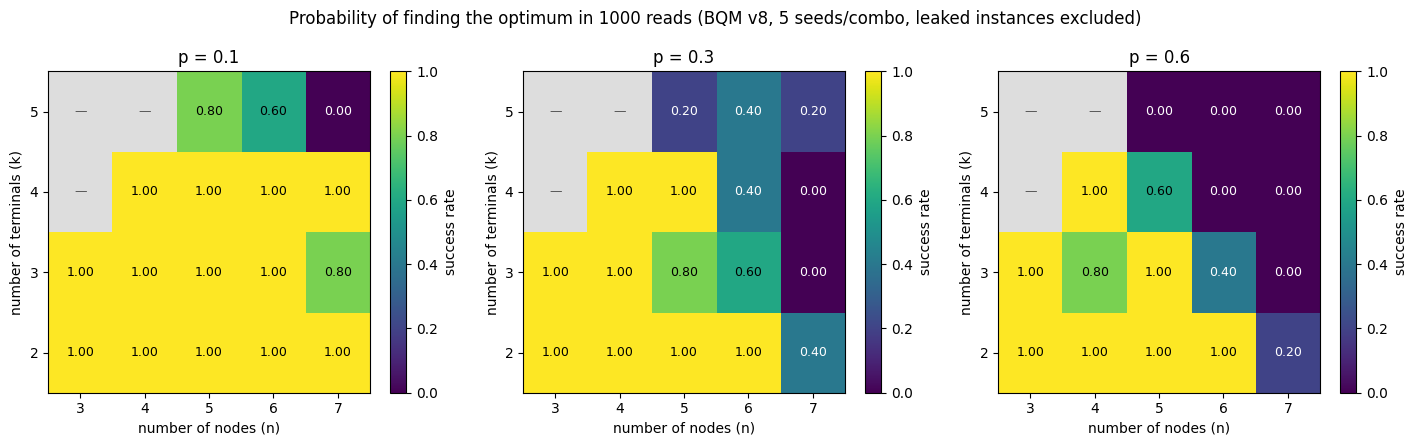

In [5]:
fig1 = plot_heatmaps(
    success_rate, p_list, n_list, k_list,
    title=(
        f"Probability of finding the optimum in {budget} reads "
        f"(BQM {VERSION_KEY}, {meta['num_instances_per_combo']} seeds/combo, "
        f"leaked instances excluded)"
    ),
    cbar_label="success rate",
    fmt="{:.2f}",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)
plt.show()

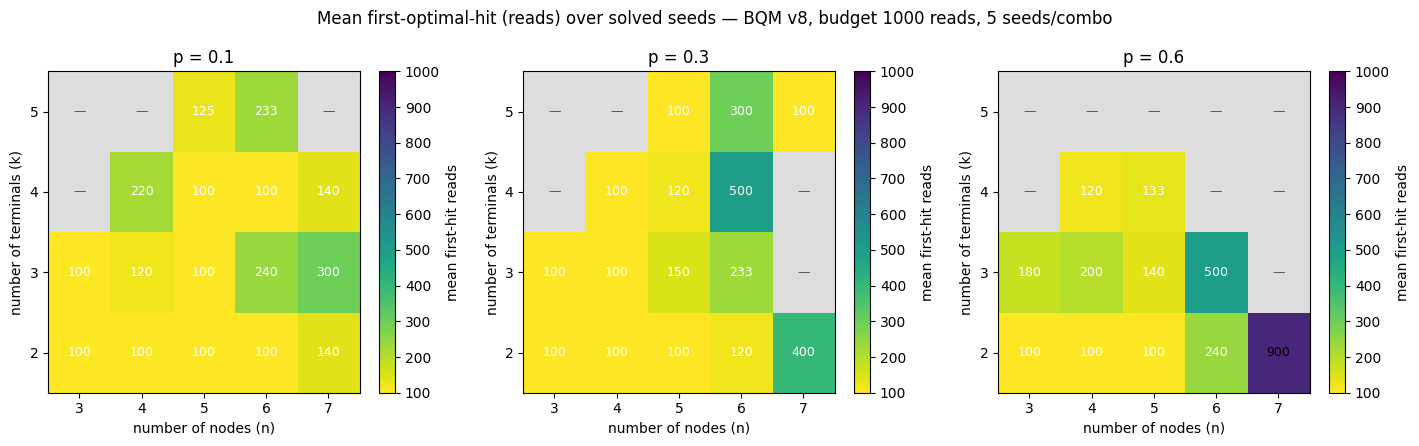

In [6]:
fig2 = plot_heatmaps(
    mean_first_hit, p_list, n_list, k_list,
    title=(
        f"Mean first-optimal-hit (reads) over solved seeds — "
        f"BQM {VERSION_KEY}, budget {budget} reads, "
        f"{meta['num_instances_per_combo']} seeds/combo"
    ),
    cbar_label="mean first-hit reads",
    fmt="{:.0f}",
    cmap="viridis_r",
    vmin=reads_per_trial,
    vmax=budget,
)
plt.show()

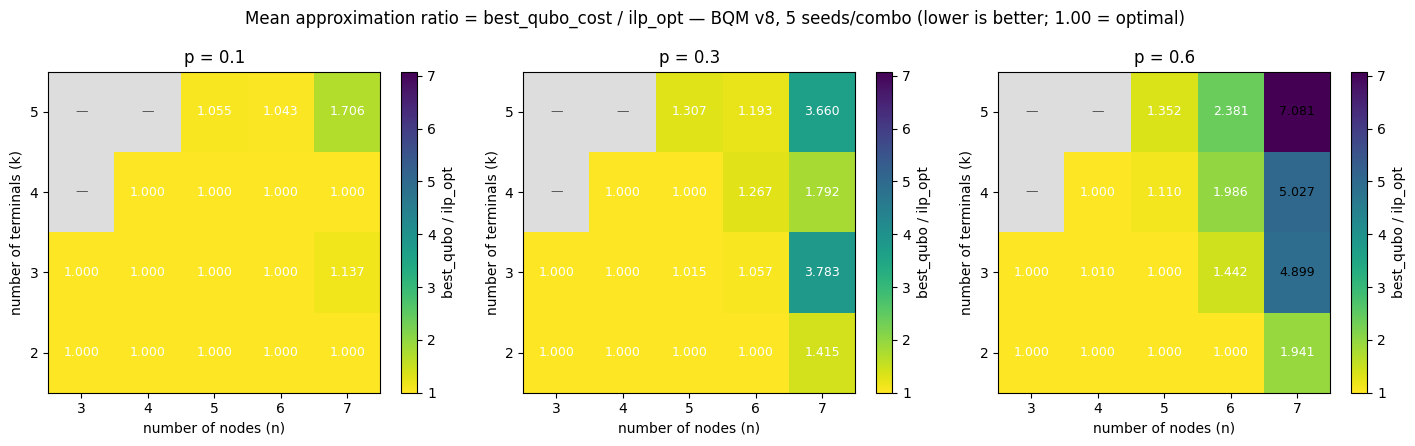

In [7]:
finite = mean_ratio[np.isfinite(mean_ratio)]
vmax_ratio = max(1.05, float(np.nanmax(mean_ratio))) if finite.size else 1.05

fig3 = plot_heatmaps(
    mean_ratio, p_list, n_list, k_list,
    title=(
        f"Mean approximation ratio = best_qubo_cost / ilp_opt — "
        f"BQM {VERSION_KEY}, {meta['num_instances_per_combo']} seeds/combo "
        f"(lower is better; 1.00 = optimal)"
    ),
    cbar_label="best_qubo / ilp_opt",
    fmt="{:.3f}",
    cmap="viridis_r",
    vmin=1.0,
    vmax=vmax_ratio,
)
plt.show()